Additional data profiling and checks on clean data.

Goals: better understanding of the data + ensuring no new issues were accidentally introduced.



Include:

* Article length
    * bar chart of article length

    * check if length field corresponds to number of words in body field. Note: might not match exactly.

* Guo's section analysis (but with cleaned data), without prediction component (this is for the analysis section).

* Time charts

    * overall (see time distribution plot from other exploration of parsed data notebook)
    
    * by publisher
    
    * by section, tracking "unclassified" ones for reference.
    
    * average article length over time


Cleaning tips:

* Table of contents with links

* SHOW_EXAMPLE_ARTICLES to toggle amount of printed info.

* Descriptions providing context

* Externalize long functions to a utils.py file, especially if used by other notebooks or scripts.

In [1]:
import pandas as pd

# load cleaned data
df = pd.read_pickle("../data/processed/cleaned_articles.pkl")

print(f"Total number of articles: {df.shape[0]:,}")

Total number of articles: 39,863


In [2]:
def clean_publisher(publisher: str) -> str:
    """Standardize publisher names by removing common variations."""
    return (
        publisher.lower()
        .replace("the ", "")
        .replace("blogs", "")
        .replace("(pennsylvania)", " ")
        .replace("(minneapolis, mn)", " ")
        .replace("(ohio)", " ")
        .strip()
    )

In [3]:
df["publisher_clean"] = df["publisher_raw"].apply(clean_publisher)
df = df.loc[df["publisher_clean"] != "february 1, 2007 thursday"]

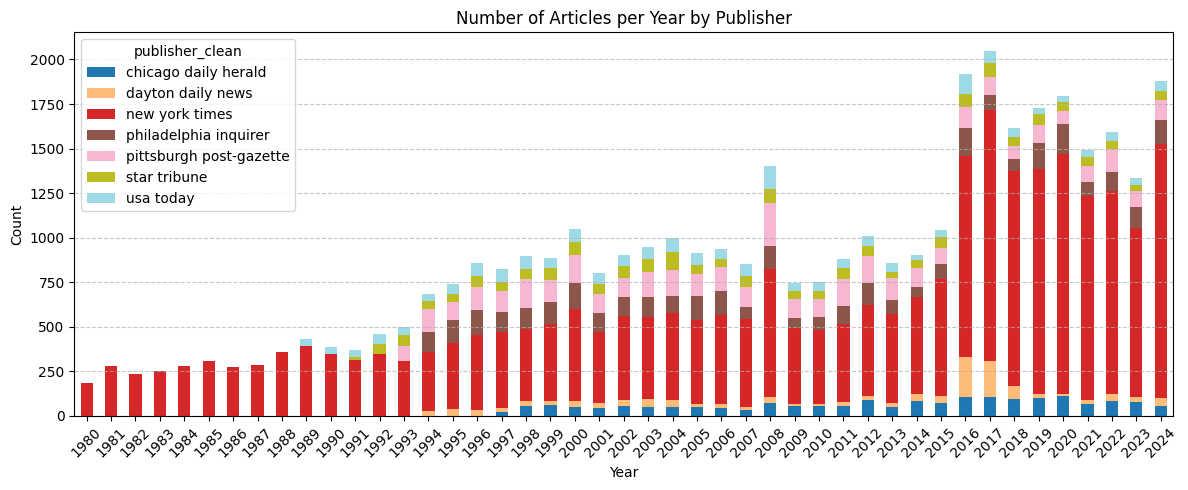

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Parse dates safely
df["parsed_date"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["parsed_date"].dt.year

# Group by year + publisher
year_pub_counts = df.groupby(["year", "publisher_clean"]).size().unstack(fill_value=0)

# Plot stacked bar chart
#plt.figure(figsize=(12, 5))
year_pub_counts.plot(
    kind="bar", stacked=True, figsize=(12, 5), colormap="tab20"
)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Number of Articles per Year by Publisher")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()
